In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import joblib

## 1-Read Data

In [2]:
df = pd.read_csv(r'C:\Users\lenovo\Downloads\Car_Price_Prediction\CAR DETAILS FROM CAR DEKHO.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [5]:
# Check unique values in categorical columns to understand our data categories
categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_columns:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in fuel: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
Unique values in seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']
Unique values in transmission: ['Manual' 'Automatic']
Unique values in owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


## 2-Transform Data

In [6]:
# Initialize LabelEncoder
le = LabelEncoder()
# Apply Label Encoding to the categorical columns
df['fuel'] = le.fit_transform(df['fuel'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['transmission'] = le.fit_transform(df['transmission'])
df['owner'] = le.fit_transform(df['owner'])

# Extract Brand and update the original 'df'
df['brand'] = df['name'].str.split(' ').str[0]

# Encode the new 'brand' column
df['brand'] = le.fit_transform(df['brand'])

# Display the first 5 rows to see the transformation
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,4,1,1,0,18
1,Maruti Wagon R LXI Minor,2007,135000,50000,4,1,1,0,18
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,1,0,10
3,Datsun RediGO T Option,2017,250000,46000,4,1,1,0,5
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,1,2,9


## 3-Model Training

In [7]:
# Define features (X) and target (y)
# We add 'brand' and remove 'name'
X = df.drop(['selling_price', 'name'], axis=1)
y = np.log1p(df['selling_price']) # Log for better accuracy

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42))
]

print("--- Accuracy with Brand Feature ---")
for name, model in final_models:
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {score * 100:.2f}%")

--- Accuracy with Brand Feature ---
Linear Regression Accuracy: 65.67%
Random Forest Accuracy: 80.53%
Gradient Boosting Accuracy: 82.53%


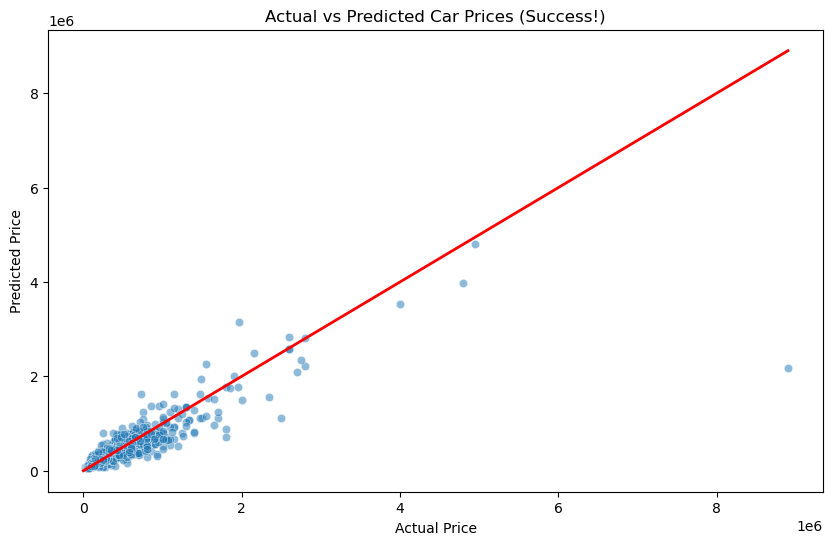

In [8]:
# 1. Use the best model (Gradient Boosting)
best_model = final_models[2][1]
y_pred_log = best_model.predict(X_test)

# 2. Plotting Real vs Predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=np.expm1(y_test), y=np.expm1(y_pred_log), alpha=0.5)
plt.plot([y_test.min(), np.expm1(y_test).max()], [y_test.min(), np.expm1(y_test).max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices (Success!)')
plt.show()

## 4-The Final Prediction Tool

In [9]:
# 1. Get the trained "Gradient Boosting" model from your list
# It is the 3rd model in your 'final_models' list (index 2)
best_model = final_models[2][1] 

# 2. Your car details
input_brand = "Hyundai" 
input_km = 60000        
input_fuel = 1          
input_seller = 1        
input_trans = 1         
input_owner = 0         
input_year = 2018       

# 3. Prepare features
brand_encoded = le.transform([input_brand])[0]
age = 2026 - input_year

# Ensure the features are in the exact order the model expects
new_car_features = [[brand_encoded, input_km, input_fuel, input_seller, input_trans, input_owner, age]]

# 4. Predict
predicted_log = best_model.predict(new_car_features)
predicted_price = np.expm1(predicted_log)

print(f"--- Prediction Result ---")
print(f"The estimated price for this {input_brand} is: {predicted_price[0]:,.2f}")

--- Prediction Result ---
The estimated price for this Hyundai is: 66,501.49


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [10]:
joblib.dump(best_model, 'car_price_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [11]:
!pip freeze > requirements.txt